In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

from data.load_data import load_hevy, load_kaggle
from data.preprocess import preprocess
from data.sequence_builder import build_sequences
from utils.split import chronological_split
from utils.scaler import fit_scaler, transform_sequences
from training.train_lstm import train_lstm
from training.finetune_lstm import finetune_lstm
from training.finetune_walk import finetune_lstm_walkforward
from training.train_baselines import train_baselines
from evaluation.evaluate_models import evaluate_all, evaluate_lstm_only, evaluate_baselines_only

LOADED FROM: C:\Users\dawso\AIML_level_300\AIML339\data\load_data.py
LOADED FROM: C:\Users\dawso\AIML_level_300\AIML339\data\preprocess.py
LOADED FROM: C:\Users\dawso\AIML_level_300\AIML339\data\sequence_builder.py
LOADED FROM: C:\Users\dawso\AIML_level_300\AIML339\utils\split.py
LOADED FROM: C:\Users\dawso\AIML_level_300\AIML339\utils\scaler.py
LOADED FROM: C:\Users\dawso\AIML_level_300\AIML339\models\lstm.py
LOADED FROM: C:\Users\dawso\AIML_level_300\AIML339\training\train_lstm.py
LOADED FROM: C:\Users\dawso\AIML_level_300\AIML339\training\finetune_lstm.py
LOADED FROM: C:\Users\dawso\AIML_level_300\AIML339\training\finetune_walk.py
LOADED FROM: C:\Users\dawso\AIML_level_300\AIML339\training\train_baselines.py
LOADED FROM: C:\Users\dawso\AIML_level_300\AIML339\evaluation\metrics.py
LOADED FROM: C:\Users\dawso\AIML_level_300\AIML339\evaluation\evaluate_models.py


In [2]:
#data prep

exercises = ['Bench Press', 'Lat Pulldown']

feature_cols = [
    'weight_kg',
    'reps',
    'session_volume',
    'prev_top_weight',
    'prev_top_reps',
    'days_since_last',
    'trend_slope'
]
target_cols = ['next_weight', 'next_reps']

seq_len = 5

hevy_path = 'data/new_workout_data.csv' #using a more recent export of my workout log
kaggle_path = 'data/Hevy_workouts_log_100_weeks.csv'

#load
hevy_raw = load_hevy(hevy_path)
kaggle_raw = load_kaggle(kaggle_path)

#prep
hevy_prep = preprocess(hevy_raw, exercises)
kaggle_prep = preprocess(kaggle_raw, exercises)

#sequence building
X_kaggle, y_kaggle = build_sequences(kaggle_prep, feature_cols, target_cols)
X_hevy, y_hevy = build_sequences(hevy_prep, feature_cols, target_cols)
exercise_titles_kaggle = kaggle_prep['exercise_title'].values[seq_len:]
exercise_titles_hevy = hevy_prep['exercise_title'].values
exercise_titles_hevy = exercise_titles_hevy[seq_len: seq_len + len(X_hevy)]



print("Kaggle Data")
print("")
print(kaggle_prep.head(3))
print("")
print("--------------------------------------------------------------------")
print("")
print("Hevy Data")
print("")
print(hevy_prep.head(3))

Kaggle Data

                    date exercise_title  reps  weight_kg  session_volume  \
7867 2023-07-10 18:44:00    Bench Press   8.0   4.000681      192.032709   
7797 2023-07-14 18:39:00    Bench Press   8.0  10.001704      509.973486   
7719 2023-08-21 03:36:00    Bench Press  10.0   8.001363      356.060648   

      prev_top_weight  prev_top_reps  time_of_day  days_since_last  \
7867         4.000681            8.0            2              6.0   
7797         4.000681            8.0            2              3.0   
7719        10.001704            8.0            3             37.0   

      trend_slope  next_weight  next_reps  
7867          0.0    10.001704        8.0  
7797          6.0     8.001363       10.0  
7719          2.0    10.001704       10.0  

--------------------------------------------------------------------

Hevy Data

                    date exercise_title  weight_kg  reps  session_volume  \
2681 2025-08-23 12:26:00    Bench Press       75.0  10.0          3

In [3]:
#scaling the data

scaler = fit_scaler(X_kaggle, X_hevy)

X_kaggle_scaled = transform_sequences(X_kaggle, scaler)
X_hevy_scaled   = transform_sequences(X_hevy, scaler)

target_scaler = StandardScaler()
target_scaler.fit(np.concatenate([y_kaggle, y_hevy], axis=0))
y_kaggle_scaled = target_scaler.transform(y_kaggle)
y_hevy_scaled   = target_scaler.transform(y_hevy)



In [4]:
#LSTM model

#pretrain on the kaggle data
pretrain_result = train_lstm(
    kaggle_sequences=X_kaggle_scaled,
    kaggle_targets=y_kaggle_scaled,
    seq_len=seq_len,
    feature_cols=feature_cols,
    epochs=20
)

pretrained_model = pretrain_result["model"]
X_test_kaggle = pretrain_result["X_test"]
y_test_kaggle = pretrain_result["y_test"]
test_idx = pretrain_result["test_idx"]
exercise_titles_test = exercise_titles_kaggle[test_idx]

print(len(pretrain_result["history"].history["loss"]))

#sliding test
walkforward_result = finetune_lstm_walkforward(
    pretrained_model=pretrained_model,
    hevy_sequences=X_hevy_scaled,
    hevy_targets=y_hevy_scaled,
    exercise_titles=exercise_titles_hevy,
    test_size=5
)

#finalize pretraining
finetune_result = finetune_lstm(
    pretrained_model=pretrained_model,
    hevy_sequences=X_hevy_scaled,
    hevy_targets=y_hevy_scaled,
    seq_len=seq_len,
    feature_cols=feature_cols,
    epochs=20
)

final_model = finetune_result["model"]

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 381ms/step - loss: 0.5780 - mae: 0.6714 - val_loss: 0.2853 - val_mae: 0.4435
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 0.4211 - mae: 0.5343 - val_loss: 0.2337 - val_mae: 0.3473
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 0.3467 - mae: 0.4241 - val_loss: 0.2250 - val_mae: 0.3139
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.3275 - mae: 0.3909 - val_loss: 0.2376 - val_mae: 0.3614
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.3318 - mae: 0.4156 - val_loss: 0.2402 - val_mae: 0.3705
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.3258 - mae: 0.4066 - val_loss: 0.2299 - val_mae: 0.3445
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 0.3148 - mae: 0.3819 - val_loss: 0.2212 - val_mae: 0.3170
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.3094 - mae: 0.3745 - val_loss: 0.2178 - val_mae: 0.3016
Epoch 9/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.3070 - mae: 0.3752 

In [5]:
hevy_test_size = 5

X_test_hevy_scaled = X_hevy_scaled[-hevy_test_size:]
y_test_hevy_raw    = y_hevy[-hevy_test_size:]
exercise_titles_test = exercise_titles_hevy[-hevy_test_size:]


In [6]:
baseline_result = train_baselines(
    kaggle_sequences_scaled=X_kaggle_scaled,
    kaggle_targets_scaled=y_kaggle_scaled,
    kaggle_sequences_raw=X_kaggle,
    kaggle_targets_raw=y_kaggle,
    seq_len=seq_len,
    feature_cols=feature_cols
)

lr_weight     = baseline_result["lr_weight"]
lr_reps       = baseline_result["lr_reps"]
gb_weight     = baseline_result["gb_weight"]
gb_reps       = baseline_result["gb_reps"]
baseline_nonml = baseline_result["baseline_nonml"]
X_test_flat   = baseline_result["X_test_flat_scaled"]
X_test_scaled = X_kaggle_scaled[baseline_result["test_idx"]]



In [7]:
#evaluate
results_lstm = evaluate_lstm_only(
    lstm_model=final_model,
    X_test_scaled=X_test_hevy_scaled,
    y_test_raw=y_test_hevy_raw,
    target_scaler=target_scaler,
    exercise_titles_test=exercise_titles_test,
    feature_names=feature_cols,
    seq_len=seq_len
)

results_baselines = evaluate_baselines_only(
    lr_weight, lr_reps,
    gb_weight, gb_reps,
    baseline_nonml,
    baseline_result["X_test_flat_scaled"],
    baseline_result["y_test_raw"],
    target_scaler
)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step


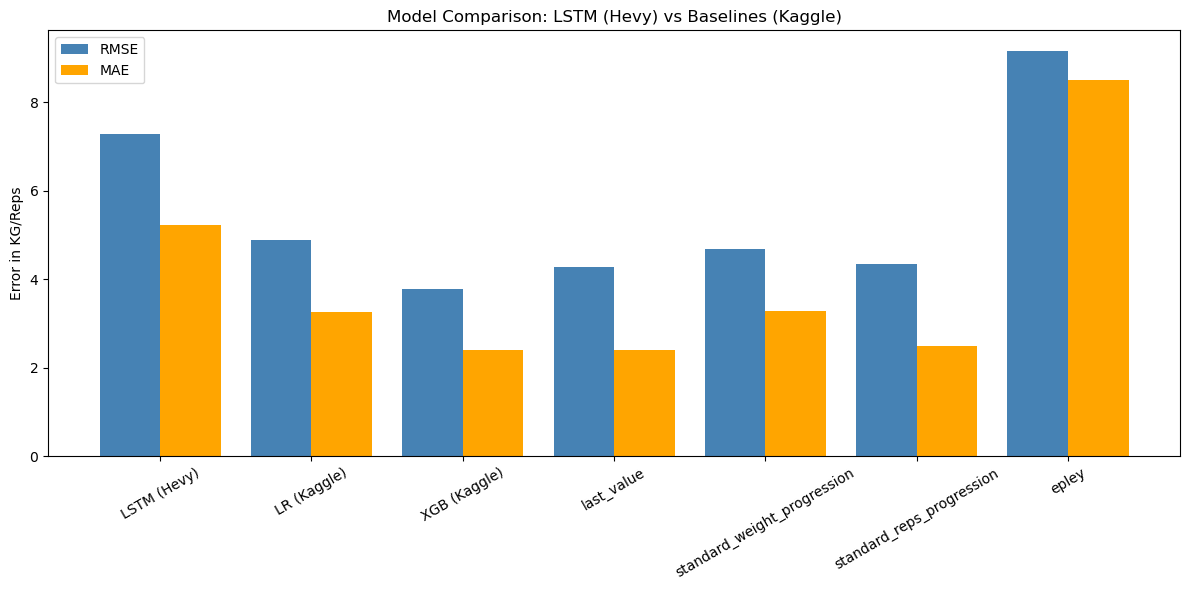

In [15]:
import matplotlib.pyplot as plt

# --- Extract LSTM metrics ---
lstm_rmse = results_lstm["lstm"]["rmse"]
lstm_mae  = results_lstm["lstm"]["mae"]

# --- Extract ML baseline metrics ---
lr_rmse   = results_baselines["lr"]["rmse"]
lr_mae    = results_baselines["lr"]["mae"]

xgb_rmse  = results_baselines["xgb"]["rmse"]
xgb_mae   = results_baselines["xgb"]["mae"]

# --- Extract ALL non‑ML baselines ---
nonml_names = list(results_baselines["nonml"].keys())
nonml_rmse_values = [results_baselines["nonml"][name]["rmse"] for name in nonml_names]
nonml_mae_values  = [results_baselines["nonml"][name]["mae"]  for name in nonml_names]

# --- Combine all model names and metrics ---
model_names = ["LSTM (Hevy)", "LR (Kaggle)", "XGB (Kaggle)"] + nonml_names
rmse_values = [lstm_rmse, lr_rmse, xgb_rmse] + nonml_rmse_values
mae_values  = [lstm_mae,  lr_mae,  xgb_mae]  + nonml_mae_values

# --- Plot ---
plt.figure(figsize=(12, 6))
x = range(len(model_names))

plt.bar(x, rmse_values, width=0.4, label="RMSE", color="steelblue")
plt.bar([i + 0.4 for i in x], mae_values, width=0.4, label="MAE", color="orange")

plt.xticks([i + 0.2 for i in x], model_names, rotation=30)
plt.ylabel("Error in KG/Reps")
plt.title("Model Comparison: LSTM (Hevy) vs Baselines (Kaggle)")
plt.legend()
plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


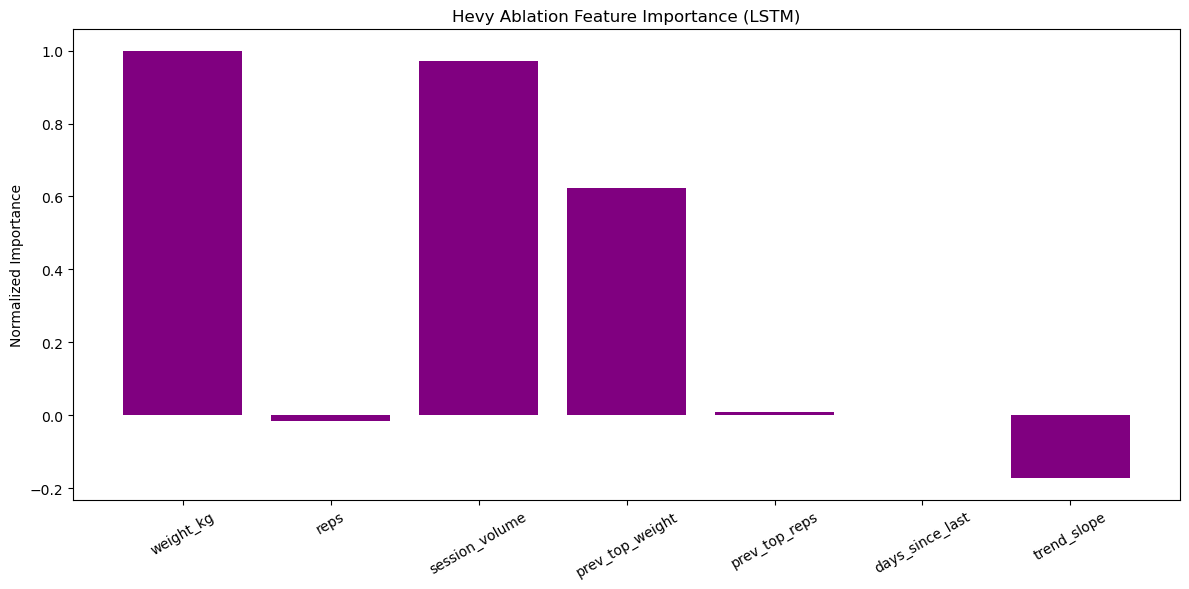

In [19]:
def ablation_importance_lstm(
    lstm_model,
    X_test_scaled,
    y_test_raw,
    target_scaler,
    feature_cols
):
    base_pred = target_scaler.inverse_transform(lstm_model.predict(X_test_scaled))
    base_rmse = np.sqrt(np.mean((y_test_raw - base_pred)**2))

    num_features = X_test_scaled.shape[2]
    importance = []

    for f in range(num_features):
        X_ablate = X_test_scaled.copy()
        X_ablate[:,:,f] = 0.0   # remove feature f

        pred_ablate = target_scaler.inverse_transform(lstm_model.predict(X_ablate))
        rmse_ablate = np.sqrt(np.mean((y_test_raw - pred_ablate)**2))

        importance.append(rmse_ablate - base_rmse)

    return np.array(importance)

# --- Compute ablation importance ---
importance = ablation_importance_lstm(
    lstm_model=final_model,
    X_test_scaled=X_test_hevy_scaled,
    y_test_raw=y_test_hevy_raw,
    target_scaler=target_scaler,
    feature_cols=feature_cols
)

# --- Normalize for plotting ---
importance_norm = importance / importance.max()

# --- Plot ---
plt.figure(figsize=(12, 6))
x = np.arange(len(feature_cols))

plt.bar(x, importance_norm, color="purple")
plt.xticks(x, feature_cols, rotation=30)
plt.ylabel("Normalized Importance")
plt.title("Hevy Ablation Feature Importance (LSTM)")
plt.tight_layout()
plt.show()



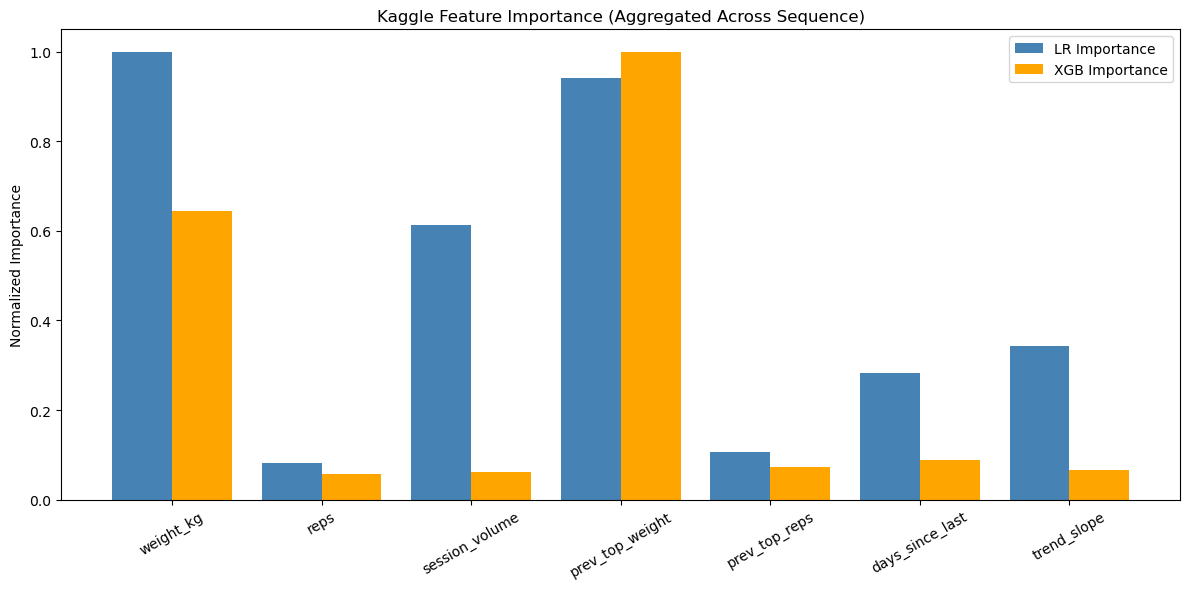

In [20]:
# Dimensions from Kaggle baseline training
seq_len = baseline_result["X_test_flat_scaled"].shape[1] // len(feature_cols)
num_features = len(feature_cols)

# --- LR importance (flattened) ---
lr_flat = np.abs(lr_weight.coef_)  # shape (seq_len * num_features)

lr_importance = np.zeros(num_features)
for i in range(num_features):
    lr_importance[i] = lr_flat[i::num_features].sum()

# --- XGB importance (flattened) ---
xgb_raw = gb_weight.get_booster().get_score(importance_type='gain')

xgb_flat = np.array([xgb_raw.get(f"f{j}", 0.0) for j in range(seq_len * num_features)])

xgb_importance = np.zeros(num_features)
for i in range(num_features):
    xgb_importance[i] = xgb_flat[i::num_features].sum()

# --- Safe normalization ---
def safe_norm(arr):
    m = arr.max()
    return arr / m if m > 0 else np.zeros_like(arr)

lr_norm = safe_norm(lr_importance)
xgb_norm = safe_norm(xgb_importance)

# --- Plot ---
plt.figure(figsize=(12, 6))
x = np.arange(num_features)

plt.bar(x - 0.2, lr_norm, width=0.4, label="LR Importance", color="steelblue")
plt.bar(x + 0.2, xgb_norm, width=0.4, label="XGB Importance", color="orange")

plt.xticks(x, feature_cols, rotation=30)
plt.ylabel("Normalized Importance")
plt.title("Kaggle Feature Importance (Aggregated Across Sequence)")
plt.legend()
plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


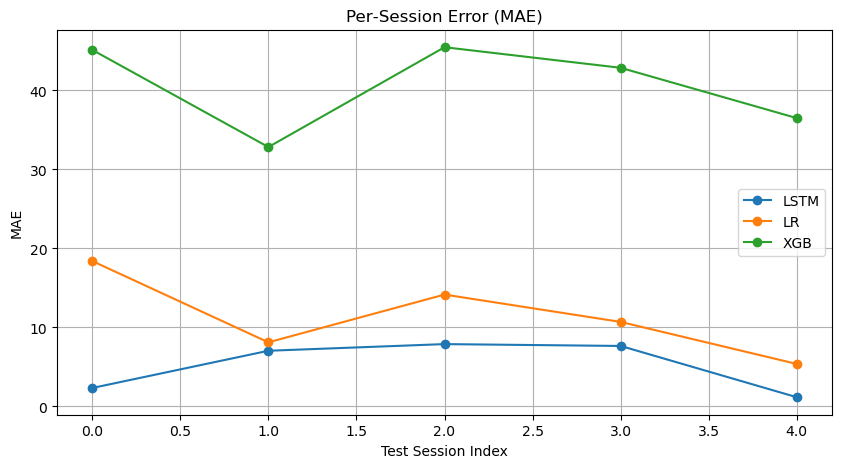

In [22]:
# LSTM predictions (inverse transform)
lstm_pred = target_scaler.inverse_transform(final_model.predict(X_test_hevy_scaled))

# Baseline predictions (Kaggle-trained baselines applied to Hevy)
X_test_flat_hevy = X_test_hevy_scaled.reshape(5, -1)

lr_pred_scaled = np.column_stack([
    lr_weight.predict(X_test_flat_hevy),
    lr_reps.predict(X_test_flat_hevy)
])
lr_pred = target_scaler.inverse_transform(lr_pred_scaled)

xgb_pred_scaled = np.column_stack([
    gb_weight.predict(X_test_flat_hevy),
    gb_reps.predict(X_test_flat_hevy)
])
xgb_pred = target_scaler.inverse_transform(xgb_pred_scaled)

# Errors per session
lstm_err = np.abs(y_test_hevy_raw - lstm_pred).mean(axis=1)
lr_err   = np.abs(y_test_hevy_raw - lr_pred).mean(axis=1)
xgb_err  = np.abs(y_test_hevy_raw - xgb_pred).mean(axis=1)

plt.figure(figsize=(10,5))
plt.plot(lstm_err, label="LSTM", marker='o')
plt.plot(lr_err, label="LR", marker='o')
plt.plot(xgb_err, label="XGB", marker='o')
plt.title("Per‑Session Error (MAE)")
plt.xlabel("Test Session Index")
plt.ylabel("MAE")
plt.legend()
plt.grid(True)
plt.show()


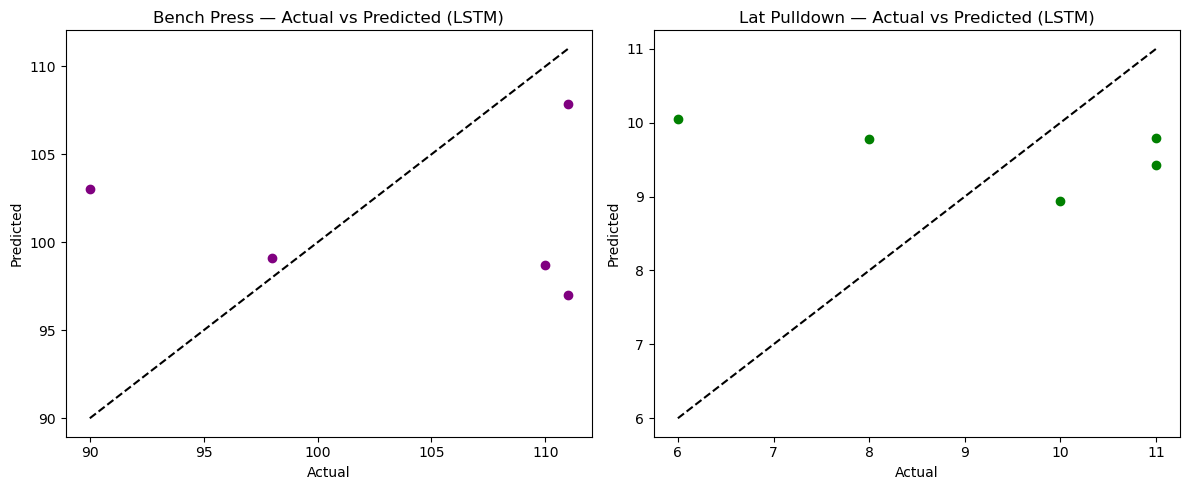

In [23]:
plt.figure(figsize=(12,5))

# Bench (column 0)
plt.subplot(1,2,1)
plt.scatter(y_test_hevy_raw[:,0], lstm_pred[:,0], color='purple')
plt.plot([y_test_hevy_raw[:,0].min(), y_test_hevy_raw[:,0].max()],
         [y_test_hevy_raw[:,0].min(), y_test_hevy_raw[:,0].max()],
         'k--')
plt.title("Bench Press — Actual vs Predicted (LSTM)")
plt.xlabel("Actual")
plt.ylabel("Predicted")

# Lat Pulldown (column 1)
plt.subplot(1,2,2)
plt.scatter(y_test_hevy_raw[:,1], lstm_pred[:,1], color='green')
plt.plot([y_test_hevy_raw[:,1].min(), y_test_hevy_raw[:,1].max()],
         [y_test_hevy_raw[:,1].min(), y_test_hevy_raw[:,1].max()],
         'k--')
plt.title("Lat Pulldown — Actual vs Predicted (LSTM)")
plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.tight_layout()
plt.show()


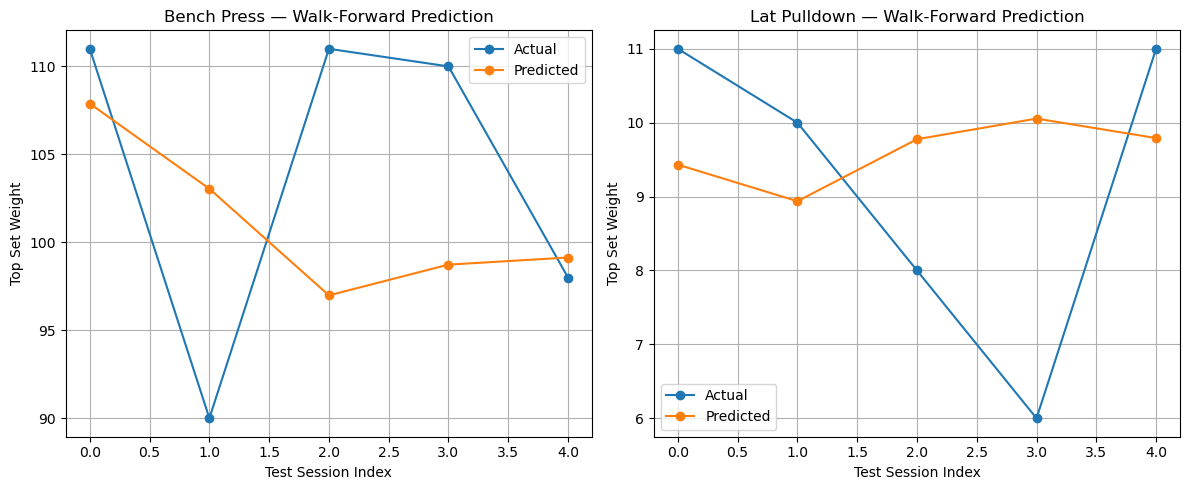

In [24]:
plt.figure(figsize=(12,5))

# Bench
plt.subplot(1,2,1)
plt.plot(y_test_hevy_raw[:,0], label="Actual", marker='o')
plt.plot(lstm_pred[:,0], label="Predicted", marker='o')
plt.title("Bench Press — Walk‑Forward Prediction")
plt.xlabel("Test Session Index")
plt.ylabel("Top Set Weight")
plt.legend()
plt.grid(True)

# Lat Pulldown
plt.subplot(1,2,2)
plt.plot(y_test_hevy_raw[:,1], label="Actual", marker='o')
plt.plot(lstm_pred[:,1], label="Predicted", marker='o')
plt.title("Lat Pulldown — Walk‑Forward Prediction")
plt.xlabel("Test Session Index")
plt.ylabel("Top Set Weight")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


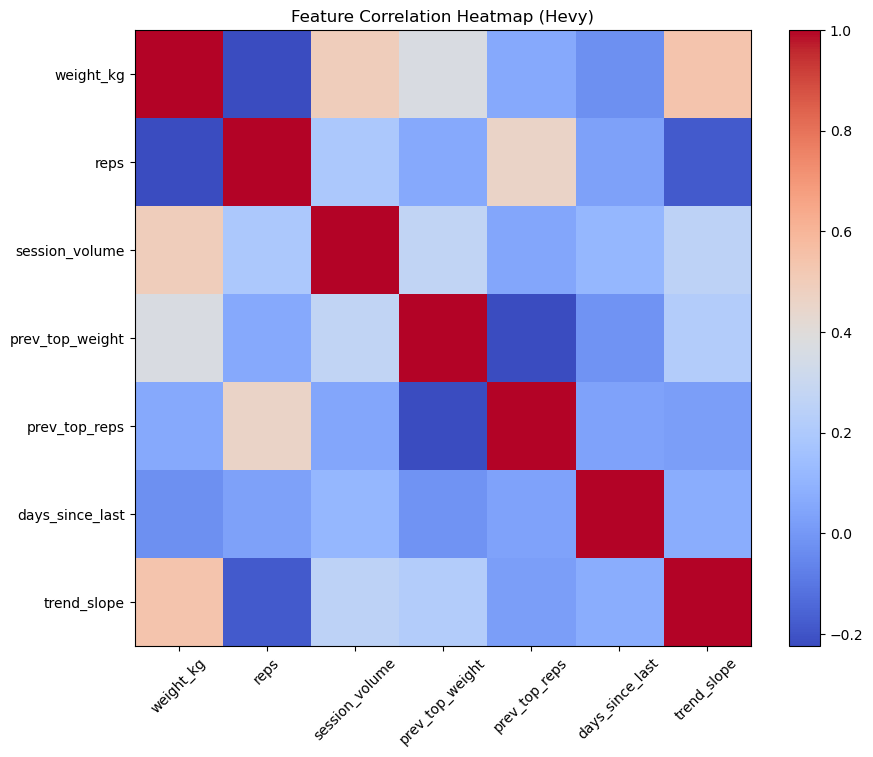

In [26]:
import pandas as pd

# Build a DataFrame from Hevy engineered features
hevy_df = pd.DataFrame(X_hevy.reshape(-1, 7), columns=feature_cols)

corr = hevy_df.corr()

plt.figure(figsize=(10,8))
plt.imshow(corr, cmap='coolwarm', interpolation='nearest')
plt.colorbar()
plt.xticks(range(len(feature_cols)), feature_cols, rotation=45)
plt.yticks(range(len(feature_cols)), feature_cols)
plt.title("Feature Correlation Heatmap (Hevy)")
plt.show()


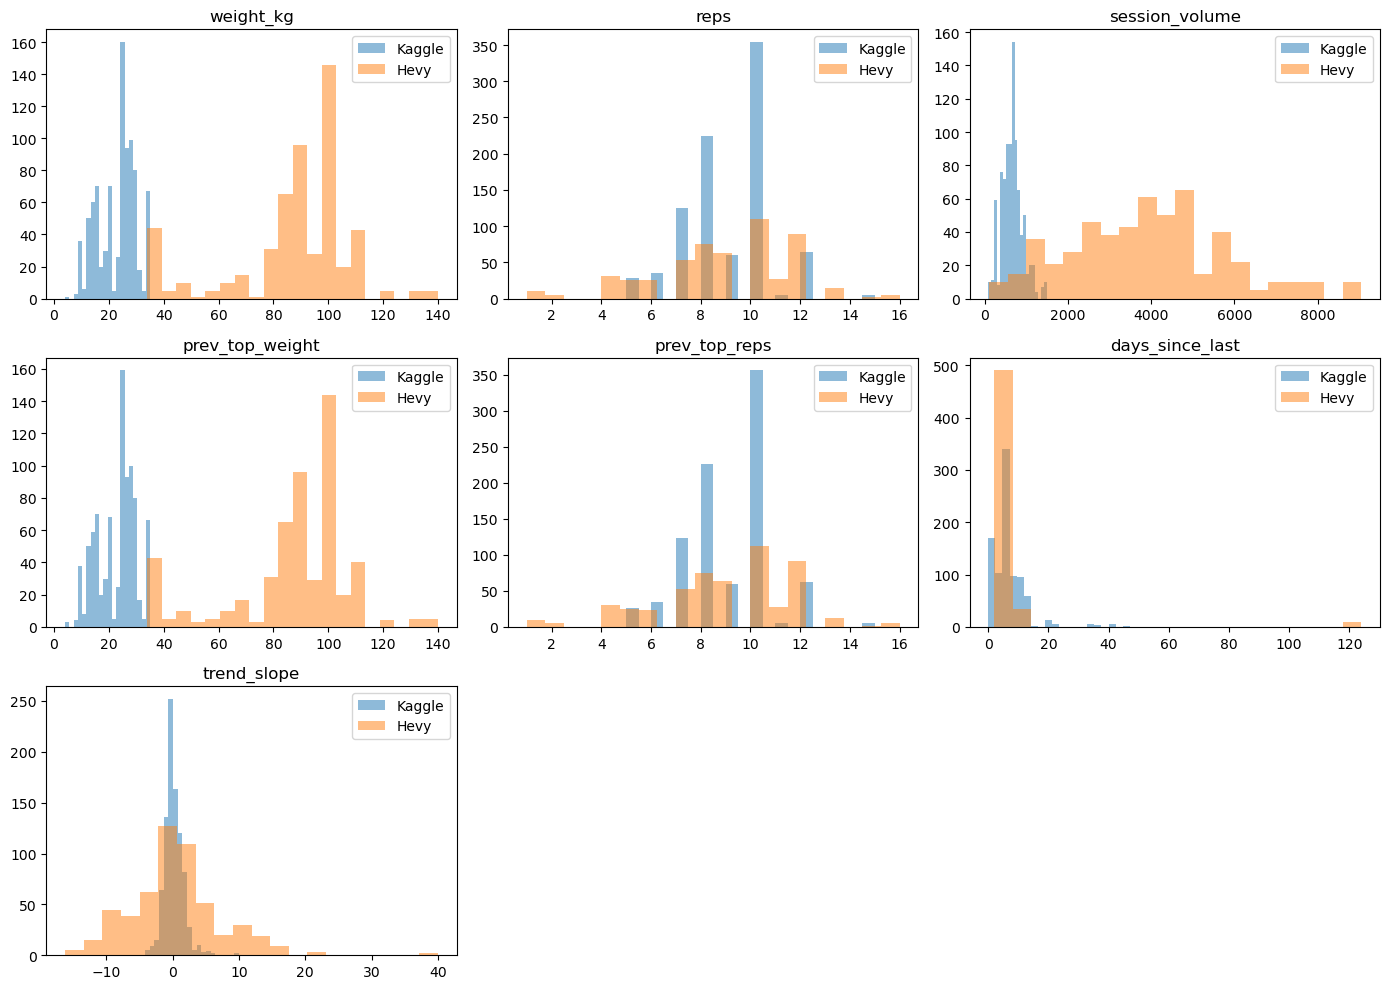

In [27]:
# Kaggle engineered features
kaggle_df = pd.DataFrame(X_kaggle.reshape(-1, 7), columns=feature_cols)
hevy_df   = pd.DataFrame(X_hevy.reshape(-1, 7), columns=feature_cols)

plt.figure(figsize=(14,10))

for i, feat in enumerate(feature_cols):
    plt.subplot(3,3,i+1)
    plt.hist(kaggle_df[feat], bins=20, alpha=0.5, label="Kaggle")
    plt.hist(hevy_df[feat], bins=20, alpha=0.5, label="Hevy")
    plt.title(feat)
    plt.legend()

plt.tight_layout()
plt.show()
